<a href="https://colab.research.google.com/github/dariashcherbakovaaa/MA_DSE_Unimi/blob/Thesis/Transfromers__1011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/Dashch/to_sent/')

Mounted at /content/drive


In [2]:
! pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 15.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from my_func import *

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

import torchvision
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

import datasets
import transformers
from transformers import AutoModel, AutoTokenizer, BertTokenizer, BertModel, BertConfig, XLMRobertaTokenizer

# data loading


In [4]:
df1 = pd.read_excel('/content/drive/MyDrive/Dashch/to_sent/Verbatim_Maxidi - Mattia.xlsx').rename(columns={'D15' : 'text'}).drop(columns=['Unnamed: 18'])
df2 = pd.read_excel('/content/drive/MyDrive/Dashch/to_sent/Verbatim_Suggerimenti_Superemme.xlsx').rename(columns={'Verbatim': 'text'})
df3 = pd.read_excel('/content/drive/MyDrive/Dashch/to_sent/Cds_verbatim.xlsx').rename(columns={'D15':'text'})

df1 = df1.iloc[: , 1:]
df2 = df2.iloc[: , 1:]
df3 = df3.iloc[:,1:]

database = pd.concat([df1, df2, df3], ignore_index=True)

database['all_codes'] = database.iloc[:, 1:].apply(lambda x: '; '.join(x.dropna()), axis=1)
data = database[['text','all_codes']].copy()
data.columns = ['text', 'label']

data = data.drop_duplicates()
data.dropna(inplace = True)
print(f"The total database size: {data.shape}")
print(f"# unique answers: {data.text.nunique()}")
print(f"# unique labels: {data.label.nunique()}")


The total database size: (2481, 2)
# unique answers: 2479
# unique labels: 740


In [5]:
labels = data.label.str.split('; ', expand=True)
data = pd.concat([data[['text']], labels], axis=1)
df = db_unite(data)
df.head(10)

,text,label
0,personale di servizio barriera casse,Casse
1,personale di servizio barriera casse,Personale
2,nella pulizia e nella professionalità dei resp...,Promozioni
3,nella pulizia e nella professionalità dei resp...,Ordine&Pulizia
4,nella pulizia e nella professionalità dei resp...,Personale
5,più varietà e scaffali ben riforniti quando ci...,Promozioni
6,più varietà e scaffali ben riforniti quando ci...,Riapprovigionamento
7,più varietà e scaffali ben riforniti quando ci...,Varietà
8,sicuramente la cortesia alle casse!!,Casse
9,sicuramente la cortesia alle casse!!,Personale


In [6]:
recoding = {
            "esposizione pdt" : 'esposizione prodotto',
            'bio': 'bio, gluten free, vegan',
            'gluten free': 'bio, gluten free, vegan',
            'vegan': 'bio, gluten free, vegan',
            'no food': 'nofood',
            'scadenze pdt': 'controllo scadenze',
            'pet food': 'petfood'
            }
df['label'] = df['label'].replace(recoding).str.lower().str.strip()

In [7]:
list_labels = df.label[df.label.map(df.label.value_counts() < 30)].unique()
print(df.label.nunique())
print(df.label.value_counts())

47
label
assortimento             529
prezzi                   435
promozioni               390
personale                361
casse                    252
ortofrutta               246
riapprovigionamento      240
qualità                  188
ordine&pulizia           188
gastronomia              158
macelleria               142
pescheria                132
varietà                  118
freschezza               111
localismi                 93
nulla                     92
panetteria                73
chiarezza prezzi          71
esposizione pdt           68
parcheggio                67
marche                    58
zzz                       47
carta fedeltà             46
controllo scadenze        38
volantini                 37
vegan                     36
spesa online              35
surgelati                 32
drug                      31
buoni pasto               28
gluten free               26
carrelli&cestini          23
bio                       23
petfood                   18
app  

In [8]:
idx_drop = df[df.label == 'zzz'].index
df.drop(idx_drop, inplace=True)
print(df.label.nunique())

46


In [9]:
database = df.groupby('text')['label'].apply(list).reset_index()
print(database.shape)

(2432, 2)


In [10]:
for idx, lists in enumerate(database['label']):
    if any(elem in list_labels for elem in lists):
        database.drop(idx, inplace=True)
database.reset_index(drop=True, inplace=True)
database.shape

(2255, 2)

In [11]:
def dataframe_creation(df):
    mlb = MultiLabelBinarizer()
    label_binarized = mlb.fit_transform(df['label'])
    df_coded = pd.DataFrame(label_binarized, columns=mlb.classes_, index=df['text'])
    df_coded.reset_index(inplace=True)
    df_coded['tag_list'] = df_coded[df_coded.columns[1:]].values.tolist()
    new_df = df_coded[['text', 'tag_list']].copy()
    new_df['label_names'] = new_df['tag_list'].apply(lambda tags: [mlb.classes_[i] for i, tag in enumerate(tags) if tag == 1])
    #new_df['label_names'] = new_df['label_names'].apply(lambda x: ", ".join(map(str, x)))
    return new_df,mlb.classes_

df, label_names = dataframe_creation(database)
df['tag_list'] = df['tag_list'].apply(lambda x: [int(i) for i in x])
df['label_count'] = df['tag_list'].apply(lambda x: x.count(1))
df.dropna(inplace = True)
df

,text,tag_list,label_names,label_count
0,Copertura Parcheggio,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[parcheggio],1
1,"Velocità nelle casse , aiuto in salumeria","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[casse],1
2,buoni spesa piu' consistenti.visto il costo ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[prezzi],1
3,i volantini con le offerte non sono così faci...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[promozioni, volantini]",2
4,il reparto ortofrutta dovrebbe essere riforni...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[ortofrutta, riapprovigionamento]",2
...,...,...,...,...
2250,è un bellissimo supermercato e super fornito m...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[prezzi],1
2251,è un insegna che si vede va bene così,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",[nulla],1
2252,"è un ottimo punto vendita,ma spesso i prezzi n...","[0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[chiarezza prezzi, esposizione pdt, riapprovig...",3
2253,è un po' trascurato: a volte dell'acqua piove ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",[ordine&pulizia],1


In [12]:
df['word_count'] = df.text.astype(str).apply(word_count)

print(f"min lenght: {np.min(df['word_count'])}")
print(f"max lenght: {np.max(df['word_count'])}")
print(f"avg lenght: {np.mean(df['word_count'])}")
print(np.percentile(df['word_count'], [95, 99]))

min lenght: 1
max lenght: 294
avg lenght: 13.36940133037694
[40. 88.]


# Transfromers setting

In [23]:
MAX_LEN = 100
TRAIN_BATCH_SIZE = 8
VALID_BATCH_SIZE = 4
EPOCHS = 25
LEARNING_RATE = 2e-05

In [24]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }


test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

In [25]:
class CustomDataset(Dataset):
  def __init__(self, dataframe, tokenizer, max_len):
    self.data = dataframe
    self.comment_text = dataframe.text
    self.targets = self.data.tag_list
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self): return len(self.comment_text)

  def __getitem__(self, index):
    comment_text = str(self.comment_text[index])
    comment_text = " ".join(comment_text.split())

    inputs = self.tokenizer.encode_plus(
        comment_text,
        None,
        add_special_tokens=True,
        max_length=self.max_len,
        pad_to_max_length=True,
        return_token_type_ids=True,
        truncation=True)

    ids = inputs['input_ids']
    mask = inputs['attention_mask']
    token_type_ids = inputs["token_type_ids"]


    return {
        'ids': torch.tensor(ids, dtype=torch.long),
        'mask': torch.tensor(mask, dtype=torch.long),
        'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
        'targets': torch.tensor(self.targets[index], dtype=torch.float)
        }

class Classifier(torch.nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.l1 = transformers.AutoModel.from_pretrained(model_checkpoint, problem_type="multi_label_classification")
        self.l2 = torch.nn.Dropout(0)
        self.l3 = torch.nn.Linear(768, 28)

    def forward(self, ids, mask, token_type_ids):
        _, output_1= self.l1(ids, attention_mask = mask, token_type_ids = token_type_ids, return_dict=False)
        output_2 = self.l2(output_1)
        output = self.l3(output_2)
        return output

In [26]:
class ModelMetrics:
    def __init__(self, model_name):
        self.model_name = model_name
        self.train_losses = []
        self.validation_losses = []
        self.precision_scores_micro = []
        self.precision_scores_macro = []
        self.recall_scores_micro = []
        self.recall_scores_macro = []
        self.f1_scores_micro = []
        self.f1_scores_macro = []
        self.roc_auc_scores = []
        self.hamming_losses = []

    def add_metrics(self, train_loss, val_loss, precision_micro, precision_macro, recall_micro, recall_macro, f1_micro, f1_macro, auc_roc, hamming_loss):
        self.train_losses.append(train_loss)
        self.validation_losses.append(val_loss)
        self.precision_scores_micro.append(precision_micro)
        self.precision_scores_macro.append(precision_macro)
        self.recall_scores_micro.append(recall_micro)
        self.recall_scores_macro.append(recall_macro)
        self.f1_scores_micro.append(f1_micro)
        self.f1_scores_macro.append(f1_macro)
        self.roc_auc_scores.append(auc_roc)
        self.hamming_losses.append(hamming_loss)

    def plot_metrics(self):
        epochs = list(range(1, len(self.train_losses) + 1))

        plt.figure(figsize=(15, 16))

        plt.subplot(3, 2, 1)
        plt.plot(epochs, self.train_losses, label='Training Loss')
        plt.plot(epochs, self.validation_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'{self.model_name} - Training and Validation Loss')

        plt.subplot(3, 2, 2)
        plt.plot(epochs, self.precision_scores_micro, label='Precision Score (Micro)')
        plt.plot(epochs, self.precision_scores_macro, label='Precision Score (Macro)')
        plt.xlabel('Epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.title(f'{self.model_name} - Precision Score per Epoch')

        plt.subplot(3, 2, 3)
        plt.plot(epochs, self.recall_scores_micro, label='Recall Score (Micro)')
        plt.plot(epochs, self.recall_scores_macro, label='Recall Score (Macro)')
        plt.xlabel('Epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.title(f'{self.model_name} - Recall Score per Epoch')

        plt.subplot(3, 2, 4)
        plt.plot(epochs, self.f1_scores_micro, label='F1 Score (Micro)')
        plt.plot(epochs, self.f1_scores_macro, label='F1 Score (Macro)')
        plt.xlabel('Epoch')
        plt.ylabel('F1 Score')
        plt.legend()
        plt.title(f'{self.model_name} - F1 Score per Epoch')

        plt.subplot(3, 2, 5)
        plt.plot(epochs, self.hamming_losses, label='Hamming Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Hamming Loss')
        plt.legend()
        plt.title(f'{self.model_name} - Hamming Loss per Epoch')

        plt.subplot(3, 2, 6)
        plt.plot(epochs, self.roc_auc_scores, label='AUC-ROC Score')
        plt.xlabel('Epoch')
        plt.ylabel('AUC-ROC')
        plt.legend()
        plt.title(f'{self.model_name} - AUC-ROC Score per Epoch')

        plt.tight_layout()
        plt.show()

In [27]:
models_metrics = {}

def train_and_validate(model, optimizer, loss_fn, training_loader, testing_loader, device, model_name):

  metrics_tracker = ModelMetrics(model_name)
  patience = 4
  best_val_loss = float('inf')
  epochs_no_improve = 0

  for epoch in range(EPOCHS):
      model.train()
      total_loss = 0
      for _, data in enumerate(training_loader, 0):
          ids = data['ids'].to(device, dtype=torch.long)
          mask = data['mask'].to(device, dtype=torch.long)
          token_type_ids = data['token_type_ids'].to(device, dtype=torch.long)
          targets = data['targets'].to(device, dtype=torch.float)
          outputs = model(ids, mask, token_type_ids)

          loss = loss_fn(outputs, targets)
          total_loss += loss.item()

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      avg_train_loss = total_loss / len(training_loader)

      model.eval()
      total_loss = 0
      fin_targets = []
      fin_outputs = []
      with torch.no_grad():
          for _, data in enumerate(testing_loader, 0):
              ids = data['ids'].to(device, dtype=torch.long)
              mask = data['mask'].to(device, dtype=torch.long)
              token_type_ids = data['token_type_ids'].to(device, dtype=torch.long)
              targets = data['targets'].to(device, dtype=torch.float)

              outputs = model(ids, mask, token_type_ids)
              loss = loss_fn(outputs, targets)
              total_loss += loss.item()

              fin_targets.extend(targets.cpu().detach().numpy().tolist())
              fin_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())

      avg_validation_loss = total_loss / len(testing_loader)

      binary_outputs = np.array(fin_outputs) >= 0.5
      precision_score_micro = metrics.precision_score(fin_targets, binary_outputs, average='micro')
      precision_score_macro = metrics.precision_score(fin_targets, binary_outputs, average='macro')
      recall_score_micro = metrics.recall_score(fin_targets, binary_outputs, average='micro')
      recall_score_macro = metrics.recall_score(fin_targets, binary_outputs, average='macro')
      f1_score_micro = metrics.f1_score(fin_targets, binary_outputs, average='micro')
      f1_score_macro = metrics.f1_score(fin_targets, binary_outputs, average='macro')
      auc_roc = metrics.roc_auc_score(fin_targets, fin_outputs, average='macro', multi_class='ovr')
      hamming_loss = metrics.hamming_loss(fin_targets, binary_outputs)

      metrics_tracker.add_metrics(avg_train_loss, avg_validation_loss, precision_score_micro, precision_score_macro,
                                  recall_score_micro, recall_score_macro, f1_score_micro, f1_score_macro, auc_roc, hamming_loss)

      print(f"Epoch: {epoch}, Training Loss: {avg_train_loss}, Validation Loss: {avg_validation_loss}, Precision Score (Micro) = {precision_score_micro}, Precision (Macro) = {precision_score_macro}, Recall Score (Micro) = {recall_score_micro}, Recall (Macro) = {recall_score_macro}, F1 Score (Micro) = {f1_score_micro}, F1 Score (Macro) = {f1_score_macro}, AUC-ROC Score = {auc_roc}, Hamming Loss = {hamming_loss}", sep = '\n')

      if avg_validation_loss < best_val_loss:
          best_val_loss = avg_validation_loss
          epochs_no_improve = 0
      else:
          epochs_no_improve += 1
          if epoch > 10 and epochs_no_improve >= patience:
              print("Early stopping condition met")

  models_metrics[model_name] = metrics_tracker

# Performance

In [28]:
train_size = 0.8
train_dataset=df[['text', 'tag_list']].sample(frac=train_size,random_state=200)
test_dataset=df[['text', 'tag_list']].drop(train_dataset.index).reset_index(drop=True)
train_dataset = train_dataset.reset_index(drop=True)


print("FULL Dataset: {}".format(df.shape))
print("TRAIN Dataset: {}".format(train_dataset.shape))
print("TEST Dataset: {}".format(test_dataset.shape))

FULL Dataset: (2255, 5)
TRAIN Dataset: (1804, 2)
TEST Dataset: (451, 2)


In [29]:
tag_array = np.array(train_dataset.tag_list.tolist())
positive_counts = np.sum(tag_array, axis=0)
negative_counts = tag_array.shape[0] - positive_counts

min_weight = 0.1
max_weight = 1.0

pos_weights = negative_counts / (positive_counts + 1e-5)
pos_weights_normalized = (pos_weights - np.min(pos_weights)) / (np.max(pos_weights) - np.min(pos_weights))
pos_weights_normalized = pos_weights_normalized * (max_weight - min_weight) + min_weight

device = 'cuda' if torch.cuda.is_available() else 'cpu'
pos_weights_tensor = torch.tensor(pos_weights_normalized, dtype=torch.float32).to(device)

print("Normalized Weights: ", pos_weights_normalized)

Normalized Weights:  [0.1        0.37080371 0.13032035 0.3054623  0.51666683 0.61866899
 0.31516047 0.21746039 0.16883933 0.25428581 0.1811082  0.34326312
 0.22124782 0.15379943 0.130971   0.28818193 0.33128895 0.10949927
 0.18217661 0.10318617 0.11037595 0.15142861 0.13197281 0.51666683
 0.64489812 0.21211742 1.         0.47178588]


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## dbmdz/bert-base-italian-cased


In [31]:
model_checkpoint = 'dbmdz/bert-base-italian-cased'
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, padding='max_length', truncation=True, return_tensors = 'pt')

training_set = CustomDataset(train_dataset, tokenizer, MAX_LEN)
testing_set = CustomDataset(test_dataset, tokenizer, MAX_LEN)

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)

model_1 = Classifier()
model_1 = model_1.to(device)

optimizer = torch.optim.Adam(params = model_1.parameters(), lr=LEARNING_RATE)
def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [32]:
train_and_validate(model_1, optimizer, loss_fn, training_loader, testing_loader, device, "bert-base-italian-cased")

Epoch: 0, Training Loss: 0.28882842207640674, Validation Loss: 0.22114026770655032, Precision Score (Micro) = 0.0, Precision (Macro) = 0.0, Recall Score (Micro) = 0.0, Recall (Macro) = 0.0, F1 Score (Micro) = 0.0, F1 Score (Macro) = 0.0, AUC-ROC Score = 0.628030805790708, Hamming Loss = 0.06580614507443776
Epoch: 1, Training Loss: 0.21050657219855132, Validation Loss: 0.19945566936404305, Precision Score (Micro) = 1.0, Precision (Macro) = 0.03571428571428571, Recall Score (Micro) = 0.0048134777376654635, Recall (Macro) = 0.0033222591362126247, F1 Score (Micro) = 0.009580838323353293, F1 Score (Macro) = 0.0060790273556231, AUC-ROC Score = 0.7020507806438154, Hamming Loss = 0.06548938866012037
Epoch: 2, Training Loss: 0.1751452005938091, Validation Loss: 0.16115830469447956, Precision Score (Micro) = 0.805699481865285, Precision (Macro) = 0.2399105408997953, Recall Score (Micro) = 0.3742478941034898, Recall (Macro) = 0.17377311354786837, F1 Score (Micro) = 0.5110928512736237, F1 Score (M

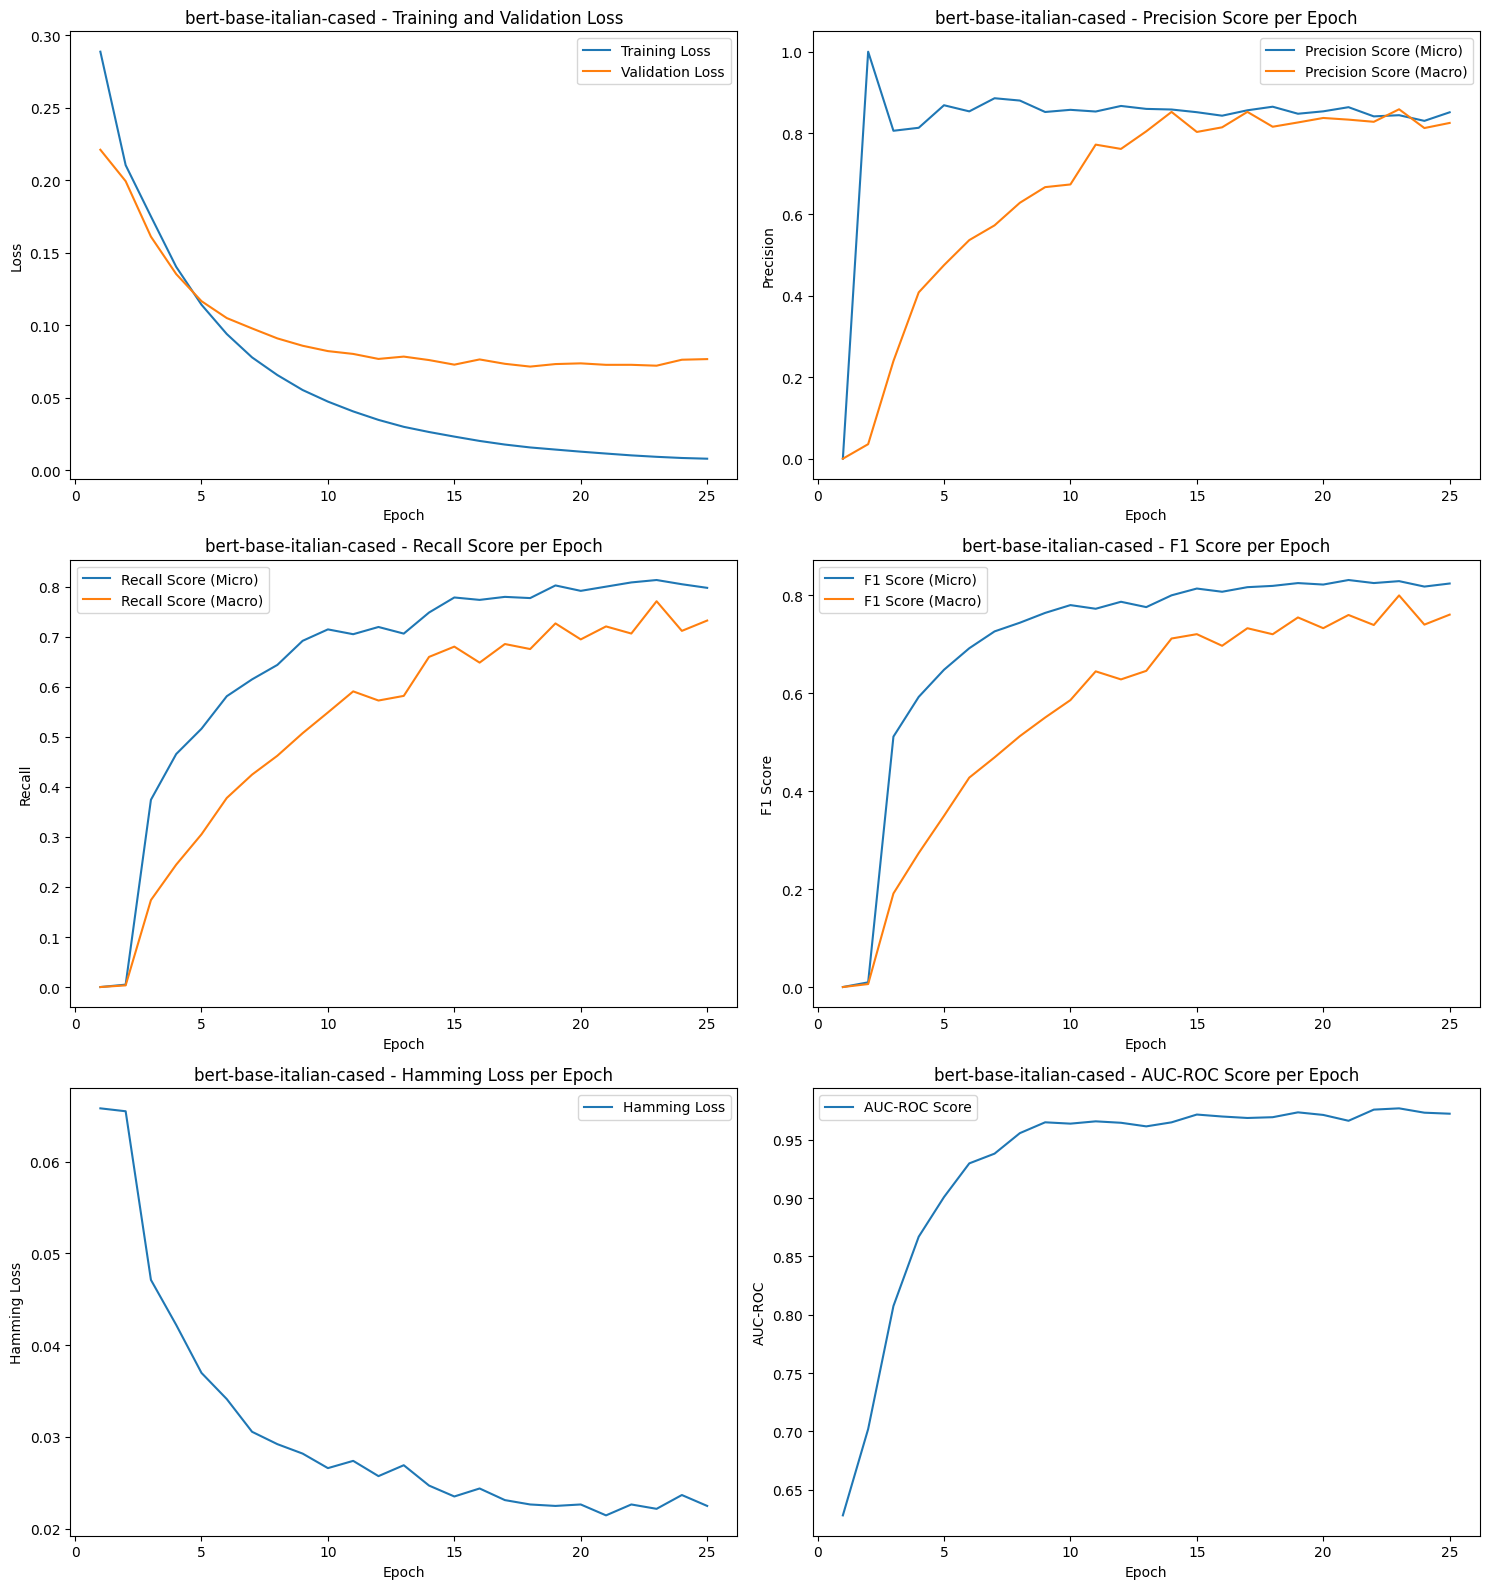

In [33]:
models_metrics["bert-base-italian-cased"].plot_metrics()

### weighted

In [34]:
model_1w = Classifier()
model_1w = model_1w.to(device)

optimizer = torch.optim.Adam(params = model_1w.parameters(), lr=LEARNING_RATE)

def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss(pos_weights_tensor)(outputs, targets)

In [35]:
train_and_validate(model_1w, optimizer, loss_fn, training_loader, testing_loader, device, "bert-base-italian-cased_weighted")

Epoch: 0, Training Loss: 0.06568970332598001, Validation Loss: 0.044436153370590335, Precision Score (Micro) = 0.0, Precision (Macro) = 0.0, Recall Score (Micro) = 0.0, Recall (Macro) = 0.0, F1 Score (Micro) = 0.0, F1 Score (Macro) = 0.0, AUC-ROC Score = 0.6037755690789254, Hamming Loss = 0.06580614507443776
Epoch: 1, Training Loss: 0.042585119629789774, Validation Loss: 0.04380030715755657, Precision Score (Micro) = 0.0, Precision (Macro) = 0.0, Recall Score (Micro) = 0.0, Recall (Macro) = 0.0, F1 Score (Micro) = 0.0, F1 Score (Macro) = 0.0, AUC-ROC Score = 0.6664055443943957, Hamming Loss = 0.06580614507443776
Epoch: 2, Training Loss: 0.04207928165529681, Validation Loss: 0.043631092966657826, Precision Score (Micro) = 0.0, Precision (Macro) = 0.0, Recall Score (Micro) = 0.0, Recall (Macro) = 0.0, F1 Score (Micro) = 0.0, F1 Score (Macro) = 0.0, AUC-ROC Score = 0.6519241534949083, Hamming Loss = 0.06580614507443776
Epoch: 3, Training Loss: 0.040588980318104796, Validation Loss: 0.0402

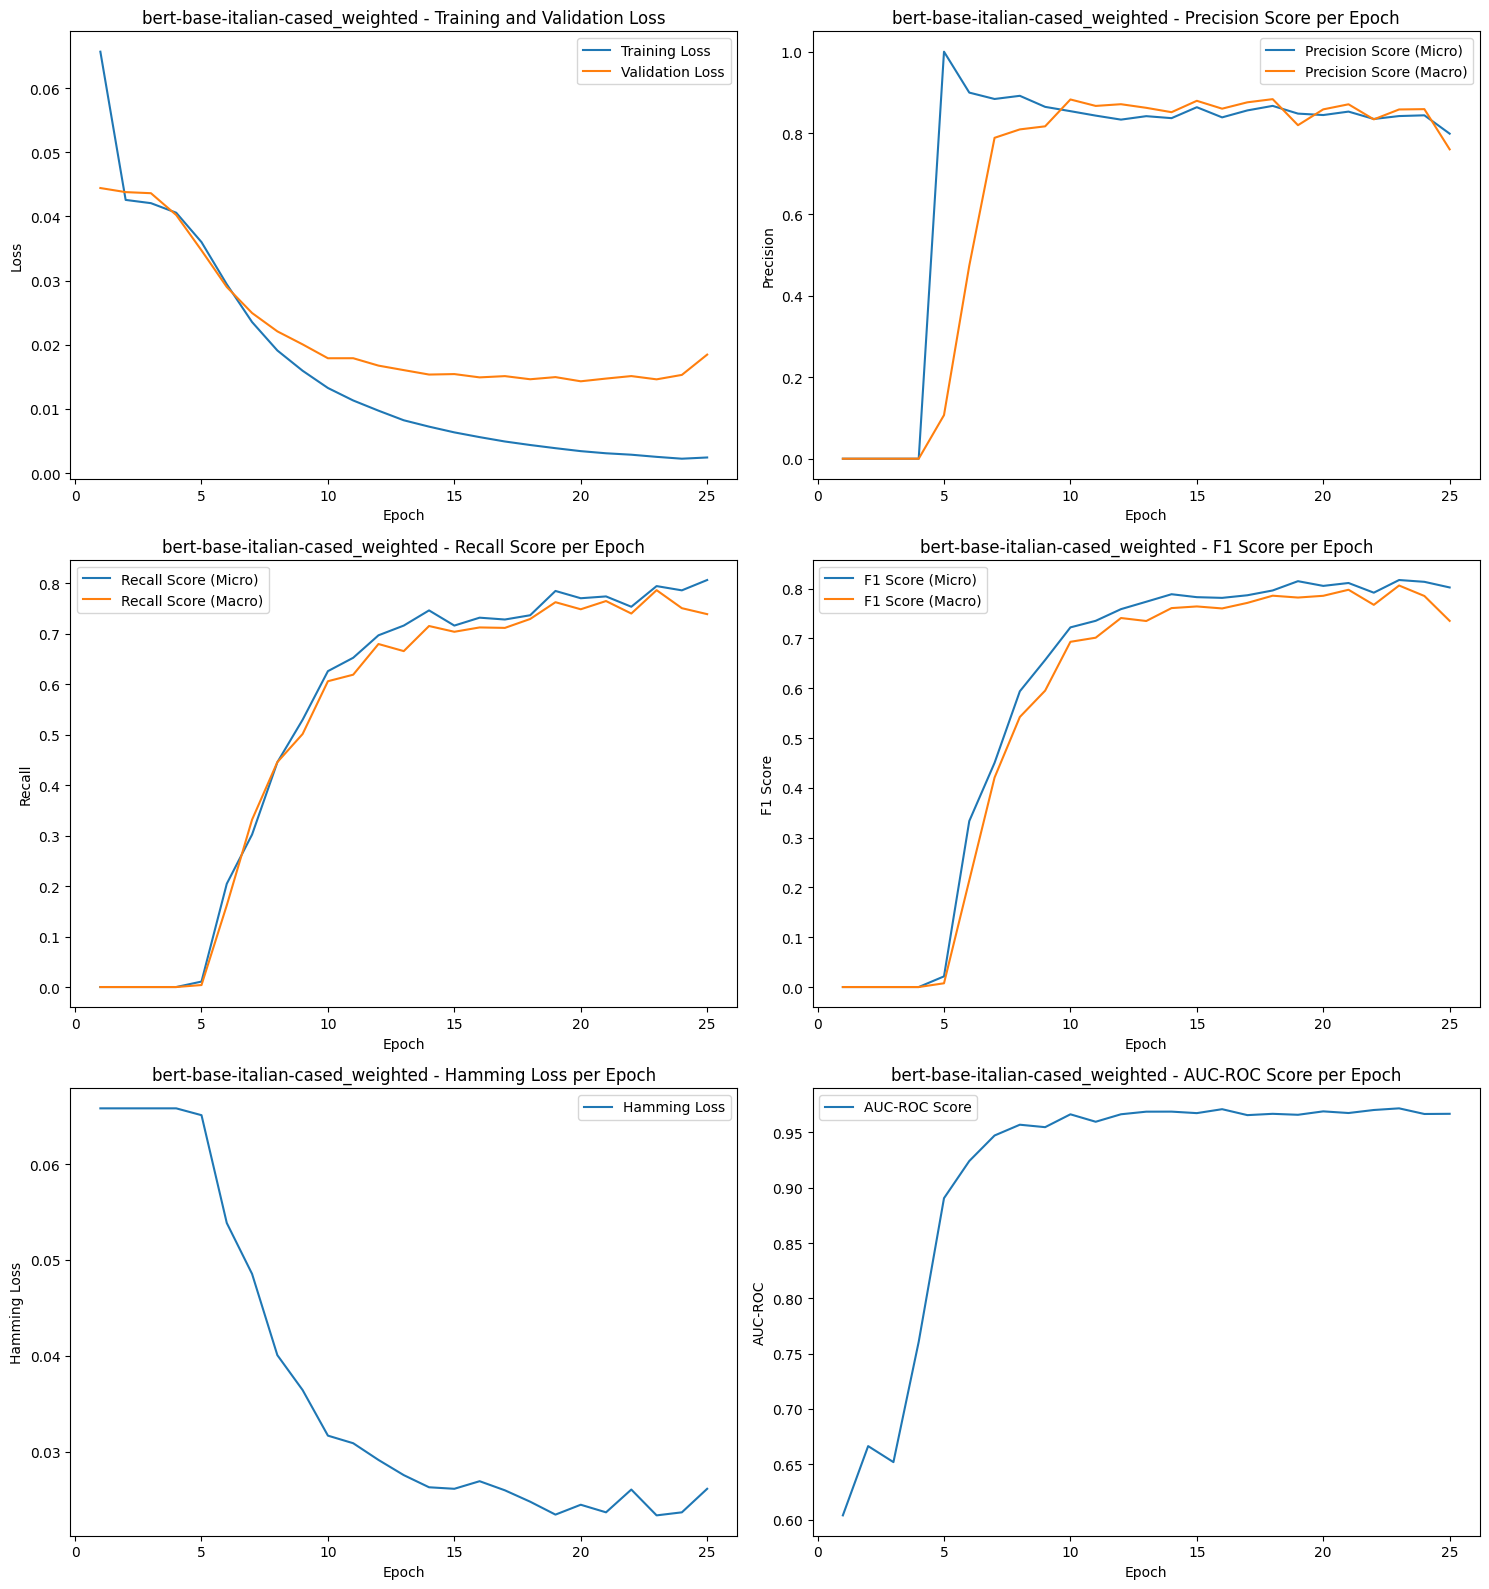

In [36]:
models_metrics["bert-base-italian-cased_weighted"].plot_metrics()

## bert-base-multilingual-cased

In [37]:
model_checkpoint = 'bert-base-multilingual-cased'
tokenizer = BertTokenizer.from_pretrained(model_checkpoint, padding='max_length', truncation=True, return_tensors = 'pt')

training_set = CustomDataset(train_dataset, tokenizer, MAX_LEN)
testing_set = CustomDataset(test_dataset, tokenizer, MAX_LEN)

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)

model_2 = Classifier()
model_2 = model_2.to(device)

optimizer = torch.optim.Adam(params = model_2.parameters(), lr=LEARNING_RATE)

def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [38]:
train_and_validate(model_2, optimizer, loss_fn, training_loader, testing_loader, device, "bert-base-multilingual-cased")

Epoch: 0, Training Loss: 0.28002845258575626, Validation Loss: 0.21471668489738904, Precision Score (Micro) = 0.0, Precision (Macro) = 0.0, Recall Score (Micro) = 0.0, Recall (Macro) = 0.0, F1 Score (Micro) = 0.0, F1 Score (Macro) = 0.0, AUC-ROC Score = 0.6763556543702014, Hamming Loss = 0.06580614507443776
Epoch: 1, Training Loss: 0.19048241384129608, Validation Loss: 0.17331811403278755, Precision Score (Micro) = 0.8571428571428571, Precision (Macro) = 0.187816913788976, Recall Score (Micro) = 0.1588447653429603, Recall (Macro) = 0.0655810118460186, F1 Score (Micro) = 0.26802030456852793, F1 Score (Macro) = 0.08849188434509996, AUC-ROC Score = 0.7811937832765542, Hamming Loss = 0.05709534368070954
Epoch: 2, Training Loss: 0.15481083451119143, Validation Loss: 0.15387721320169162, Precision Score (Micro) = 0.8072916666666666, Precision (Macro) = 0.24775764961124327, Recall Score (Micro) = 0.3730445246690734, Recall (Macro) = 0.18637795479770805, F1 Score (Micro) = 0.5102880658436214, 

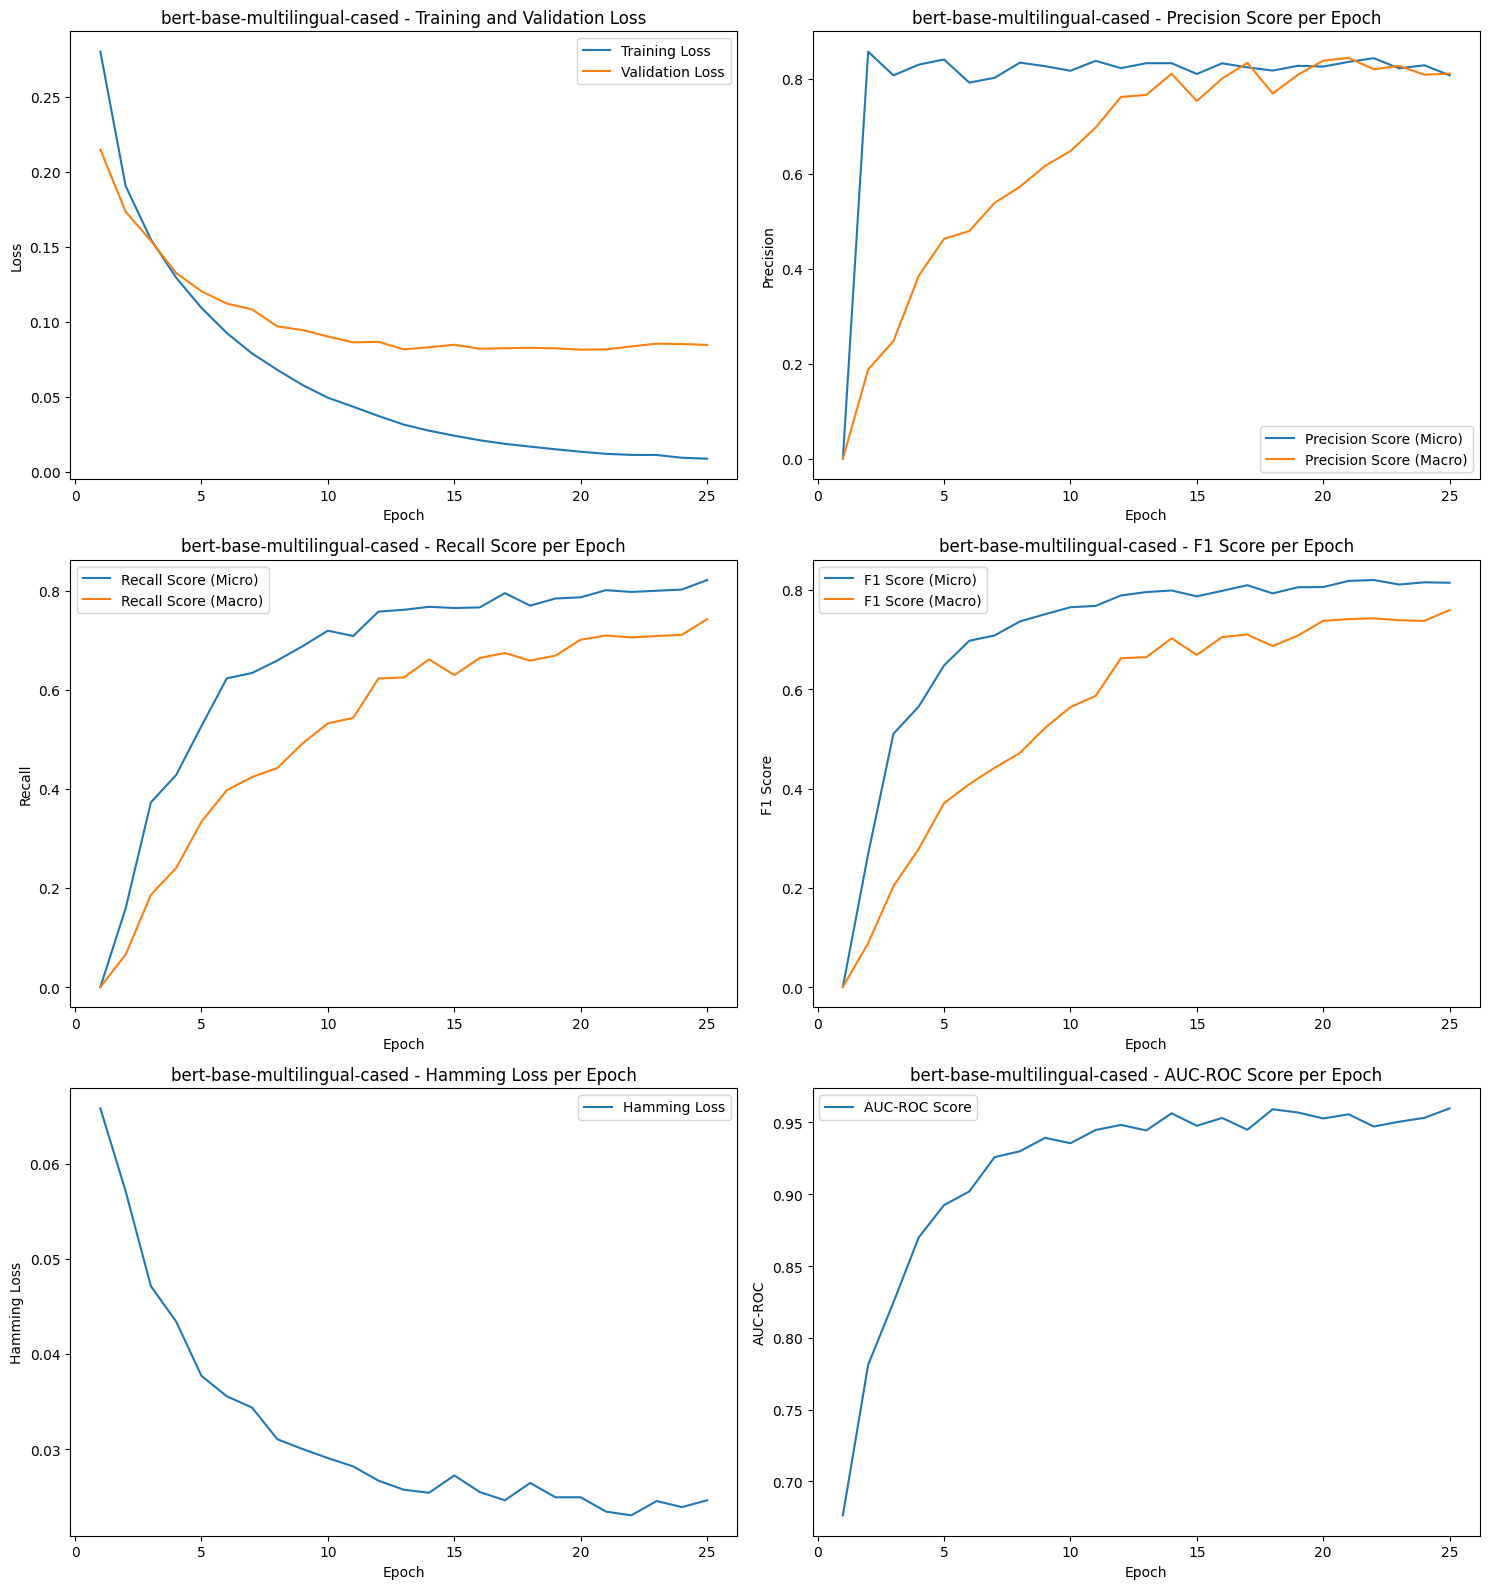

In [39]:
models_metrics["bert-base-multilingual-cased"].plot_metrics()

### weighted

In [40]:
model_2w = Classifier()
model_2w = model_2w.to(device)

optimizer = torch.optim.Adam(params = model_2w.parameters(), lr=LEARNING_RATE)

def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss(pos_weights_tensor)(outputs, targets)

In [ ]:
train_and_validate(model_2w, optimizer, loss_fn, training_loader, testing_loader, device, "bert-base-multilingual-cased_weighted")

Epoch: 0, Training Loss: 0.06358962884354116, Validation Loss: 0.04440639796048666, Precision Score (Micro) = 0.0, Precision (Macro) = 0.0, Recall Score (Micro) = 0.0, Recall (Macro) = 0.0, F1 Score (Micro) = 0.0, F1 Score (Macro) = 0.0, AUC-ROC Score = 0.6461902326348357, Hamming Loss = 0.06580614507443776
Epoch: 1, Training Loss: 0.04240531267482886, Validation Loss: 0.0438189307573886, Precision Score (Micro) = 0.0, Precision (Macro) = 0.0, Recall Score (Micro) = 0.0, Recall (Macro) = 0.0, F1 Score (Micro) = 0.0, F1 Score (Macro) = 0.0, AUC-ROC Score = 0.6320515876729554, Hamming Loss = 0.06580614507443776
Epoch: 2, Training Loss: 0.04080148103885946, Validation Loss: 0.041051140236379825, Precision Score (Micro) = 0.0, Precision (Macro) = 0.0, Recall Score (Micro) = 0.0, Recall (Macro) = 0.0, F1 Score (Micro) = 0.0, F1 Score (Macro) = 0.0, AUC-ROC Score = 0.7759292653549513, Hamming Loss = 0.06580614507443776
Epoch: 3, Training Loss: 0.03673202143899635, Validation Loss: 0.03515118

In [ ]:
models_metrics["bert-base-multilingual-cased_weighted"].plot_metrics()

## xlm-roberta-base

In [ ]:
model_checkpoint = "xlm-roberta-base"
tokenizer = XLMRobertaTokenizer.from_pretrained(model_checkpoint,  padding='max_length', truncation=True, return_tensors = 'pt')
training_set = CustomDataset(train_dataset, tokenizer, MAX_LEN)
testing_set = CustomDataset(test_dataset, tokenizer, MAX_LEN)

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)

model_3 = Classifier()
model_3 = model_3.to(device)

optimizer = torch.optim.Adam(params = model_3.parameters(), lr=LEARNING_RATE)

def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [ ]:
train_and_validate(model_3, optimizer, loss_fn, training_loader, testing_loader, device, "xlm-roberta-base")

In [ ]:
models_metrics["xlm-roberta-base"].plot_metrics()

### weighted

In [ ]:
model_3w = Classifier()
model_3w = model_3w.to(device)

optimizer = torch.optim.Adam(params = model_3w.parameters(), lr=LEARNING_RATE)

def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss(pos_weights_tensor)(outputs, targets)

In [ ]:
train_and_validate(model_3w, optimizer, loss_fn, training_loader, testing_loader, device, "xlm-roberta-base_weighted")

In [ ]:
models_metrics["xlm-roberta-base_weighted"].plot_metrics()

## Musixmatch/umberto-commoncrawl-cased-v1

In [ ]:
model_checkpoint ='Musixmatch/umberto-commoncrawl-cased-v1'
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint,  padding='max_length', truncation=True, return_tensors = 'pt')

training_set = CustomDataset(train_dataset, tokenizer, MAX_LEN)
testing_set = CustomDataset(test_dataset, tokenizer, MAX_LEN)

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)

model_4 = Classifier()
model_4 = model_4.to(device)

optimizer = torch.optim.Adam(params = model_4.parameters(), lr=LEARNING_RATE)

def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [ ]:
train_and_validate(model_4, optimizer, loss_fn, training_loader, testing_loader, device, "umberto")

In [ ]:
models_metrics["umberto"].plot_metrics()

### weighted

In [ ]:
model_4w = Classifier()
model_4w = model_4w.to(device)

optimizer = torch.optim.Adam(params = model_4w.parameters(), lr=LEARNING_RATE)

def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss(pos_weights_tensor)(outputs, targets)

In [ ]:
train_and_validate(model_4w, optimizer, loss_fn, training_loader, testing_loader, device, "umberto_weighted")

In [ ]:
models_metrics["umberto_weighted"].plot_metrics()